In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("smartCartDataset.csv")

In [3]:
print(df.head())
print(df.shape)

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  MntFishProducts  MntSweetProducts  \
0  04-09-2012       58       635  ...              172                88   
1  08-03-2014       38        11  ...                2                 1   
2  21-08-2013       26       426  ...              111                21   
3  10-02-2014       26        11  ...               10                 3   
4  19-01-2014       94       173  ...               46                27   

   MntGoldProds  NumDealsPurchases  NumWebPurchases  NumCatalogPurchases  

In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

# 1. Handle missing values

In [5]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [6]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# Feature Engineering

In [7]:
#Age
df["Age"]=2026-df["Year_Birth"]

In [8]:
df.sample()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
610,7930,1969,Master,Single,26877.0,0,0,19-08-2013,74,101,...,18,40,2,3,1,6,6,0,0,57


In [9]:
#Customer Tenure Days
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
reference_date=df["Dt_Customer"].max()
df["customer_tenure"]=(reference_date-df["Dt_Customer"]).dt.days

In [10]:
#Total Spending and total children
df["Total_Spending"]=df["MntFishProducts"]+df["MntFruits"]+df["MntGoldProds"]
+df["MntMeatProducts"]+df["MntSweetProducts"]+df["MntWines"]

df["Total_Children"]=df["Kidhome"]+df["Teenhome"]

In [11]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,348,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,9,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,202,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,19,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,104,1


In [12]:
#Education 
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [13]:
# Lets convert education data to 3 types only
df["Education"]=df["Education"].replace(
    {
        "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
        "Graduation": "Graduate",
        "PhD": "Postgraduate","Master": "Postgraduate"
    }
)

In [14]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [15]:
#Marital Status
df["Living_With"]=df["Marital_Status"].replace(
    {
        "Married":"Partner","Together": "Partner",
        "Single": "Alone","Divorced":"Alone","Widow":"Alone","Absurd":"Alone","YOLO":"Alone"
    }
)

In [16]:
 df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

# Drop Columns

In [17]:
df.head()
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_tenure', 'Total_Spending',
       'Total_Children', 'Living_With'],
      dtype='object')

In [18]:
cols_to_drop=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer","MntWines","MntFruits",
     "MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
df_cleaned=df.drop(columns=cols_to_drop)

In [19]:
df_cleaned.head()
df_cleaned.shape

(2240, 15)

# Outliers

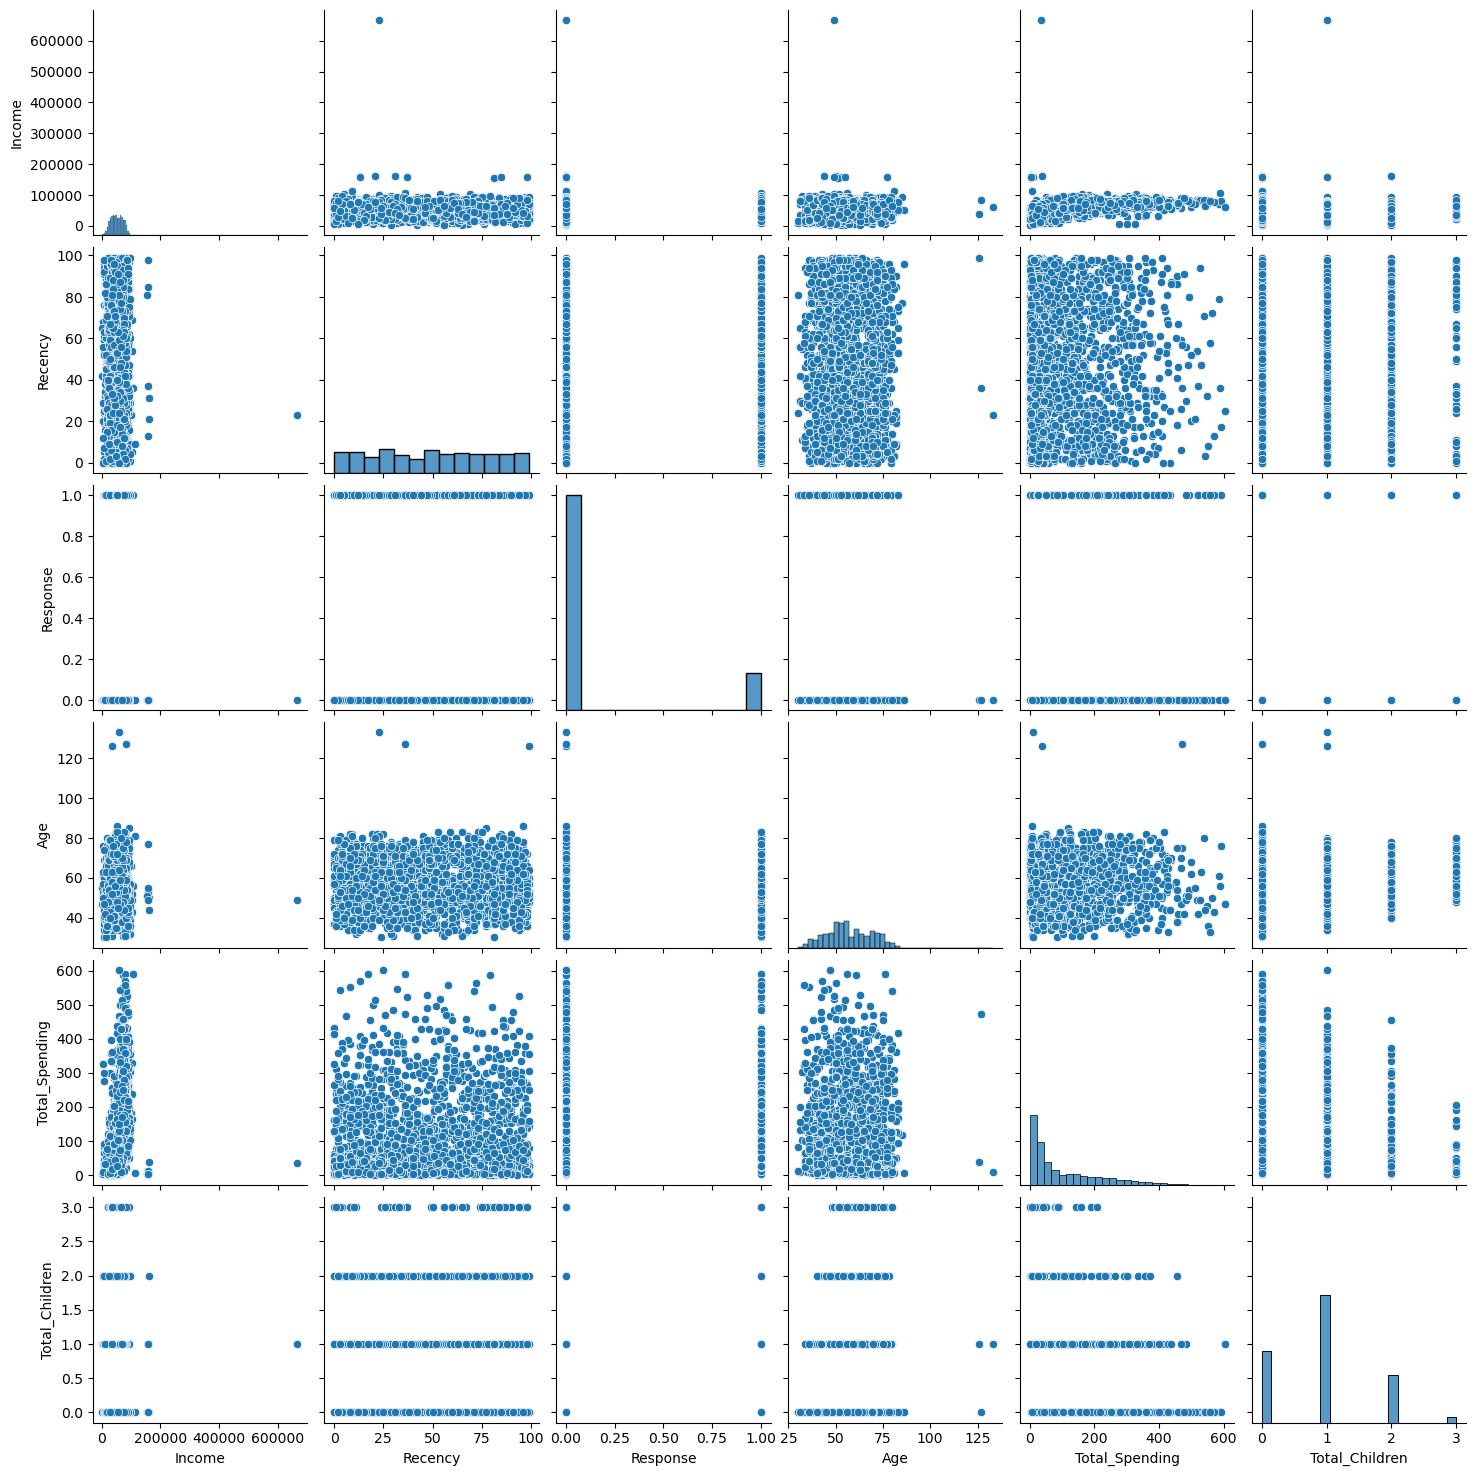

In [20]:
cols = ["Income","Recency","Response","Age" ,"Total_Spending","Total_Children"]

#Relative plots of some features - Pair Plots
sns.pairplot(df_cleaned[cols])

In [24]:
#Remove outliers

print("data size with outliers: ", len(df_cleaned))

df_cleaned= df_cleaned[(df_cleaned["Age"] < 90 )]
df_cleaned= df_cleaned[(df_cleaned["Income"] < 600_000 )]

print("data size without outliers: ", len(df_cleaned))

data size with outliers:  2240
data size without outliers:  2236


# Heatmap

In [25]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

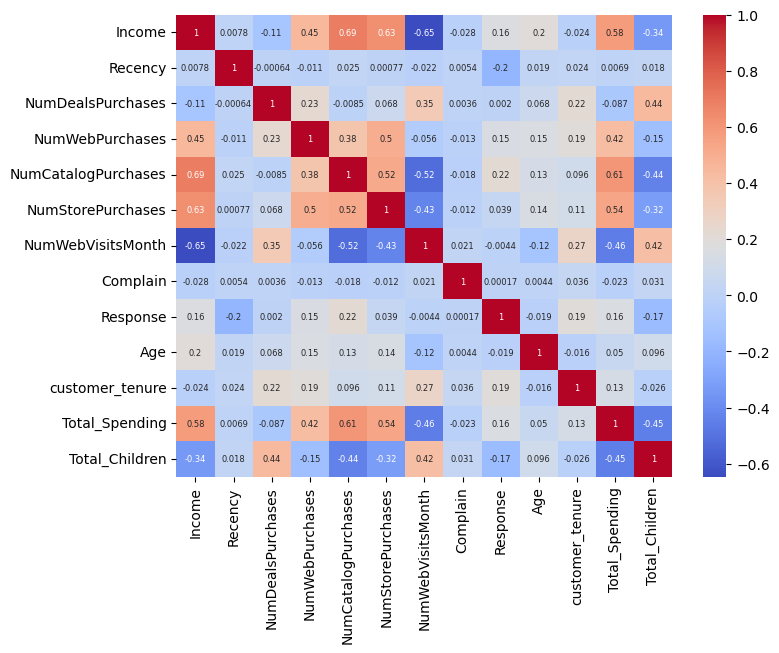

In [26]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
    
)

# Encoding

In [34]:
from sklearn.preprocessing import OneHotEncoder

In [37]:
ohe = OneHotEncoder()

categorical_cols=["Education","Living_With"]

enc_cols= ohe.fit_transform(df_cleaned[categorical_cols])

In [38]:
enc_df=pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(categorical_cols), index=df_cleaned.index)

In [39]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [40]:
df_encoded = pd.concat([df_cleaned.drop(columns=categorical_cols),enc_df], axis=1)

In [42]:
df_encoded.shape

(2236, 18)

# Scaling

In [44]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X=df_encoded

In [45]:
X_scaled=scaler.fit_transform(X )

# Visualize

In [46]:
X_scaled.shape

(2236, 18)

In [83]:
#2D 
from sklearn.decomposition import PCA
pca=PCA(n_components=3)

In [84]:
X_pca=pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3D Projection')

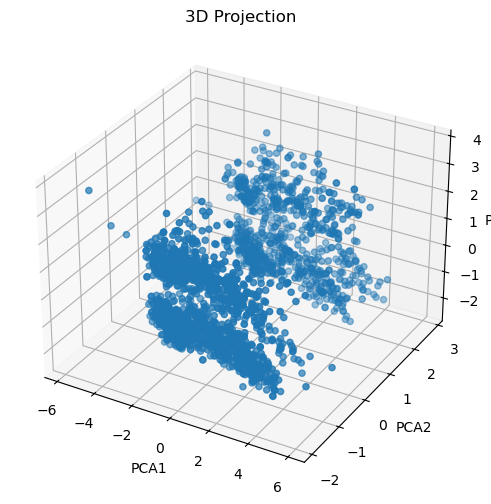

In [85]:
#Plot
fig = plt.figure(figsize=(8,6)) 
ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1], X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Projection")

In [86]:
pca.explained_variance_ratio_

array([0.21738159, 0.11384925, 0.10555896])

# Analyze K value
## 1. Elbow Method

In [87]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [88]:
knee = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [89]:
print("Best k: ",optimal_k)

Best k:  5


Text(0, 0.5, 'wcss')

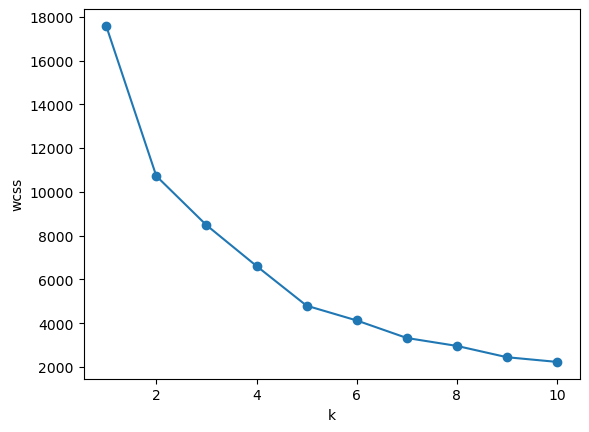

In [93]:
# Plot

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("k")
plt.ylabel("wcss")

## 2. Silhoutte Score

In [94]:
from sklearn.metrics import silhouette_score
scores=[]

for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)

Text(0, 0.5, 'silhouette score ')

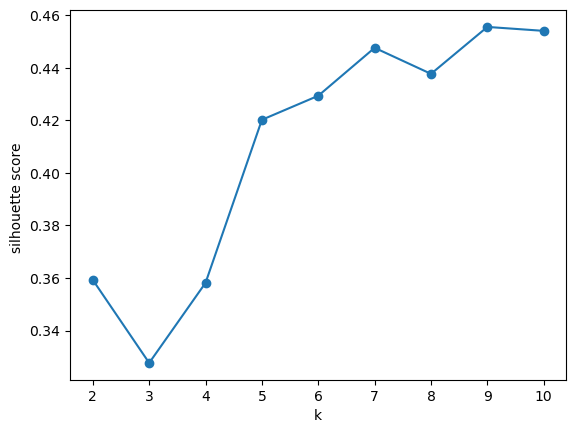

In [95]:
#Plot

plt.plot(range(2,11), scores, marker='o')
plt.xlabel("k")
plt.ylabel("silhouette score ")

Text(0, 0.5, 'scores')

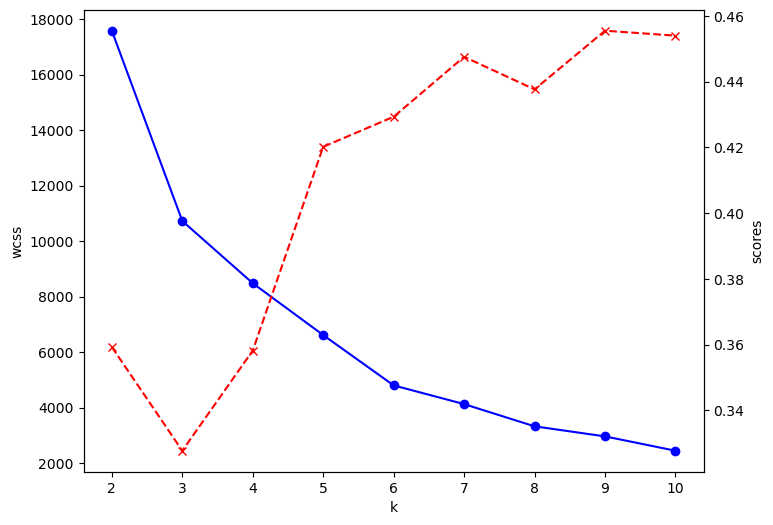

In [107]:
# Comined plot for both the values

k_range = range(2,11)

fig, ax1 =plt.subplots(figsize=(8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker='o',color="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")

ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)], marker='x',color="red",linestyle="--")
ax2.set_ylabel("scores")

# Clustering

In [110]:
# kmeans
kmeans=KMeans(n_clusters=4,random_state=42)
labels_kmeans=kmeans.fit_predict(X_pca)

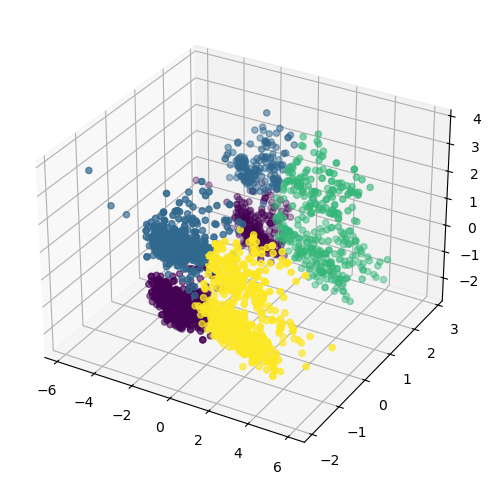

In [112]:
fig = plt.figure(figsize=(8,6))

ax =fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1], X_pca[:,2], c=labels_kmeans)

In [113]:
#Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

In [114]:
agg_clf=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg_clf.fit_predict(X_pca)

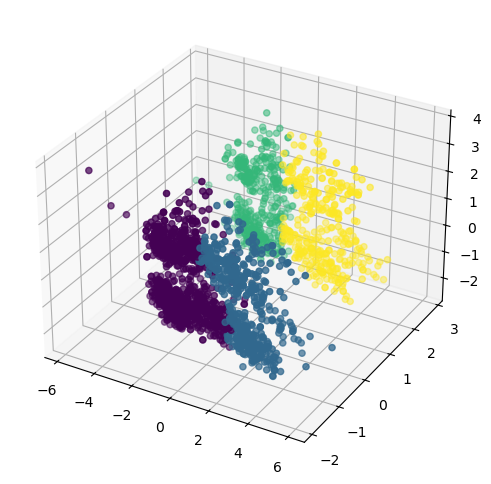

In [115]:
#plot
fig = plt.figure(figsize=(8,6))

ax =fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1], X_pca[:,2], c=labels_agg)

# Characterization of clusters

In [135]:
X["clusters"]= labels_agg

In [136]:
 X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,348,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,9,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,202,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,19,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,104,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

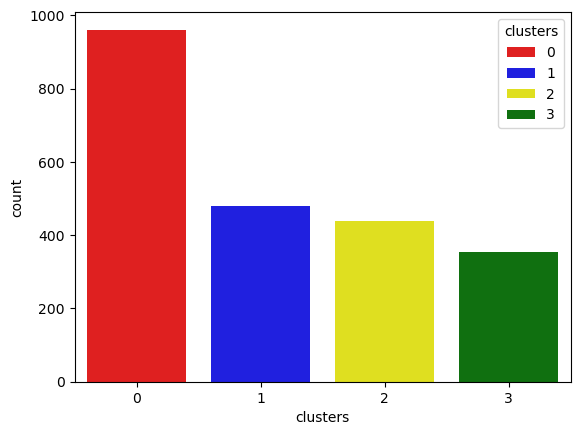

In [137]:
pal = ["red","blue","yellow","green"]

sns.countplot(x=X["clusters"], palette=pal, hue =X["clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

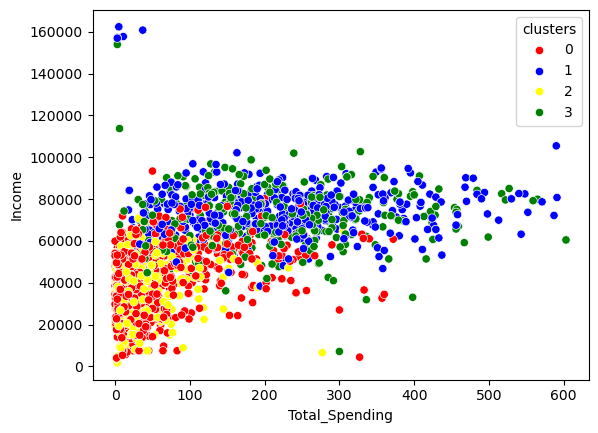

In [138]:
# Comparision of income and spending patterns

sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue = X["clusters"], palette=pal)

In [140]:
# Cluster summary

cluster_summary =  X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         40802.819979  49.325702           2.660770         3.300728   
1         74003.390852  48.467775           1.773389         5.654886   
2         37296.323462  48.266515           2.553531         2.735763   
3         70382.585915  50.478873           1.887324         5.766197   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    1.138398           4.357960           6.351717  0.010406   
1                    5.652807           8.704782           3.274428  0.006237   
2                    0.829157           3.640091           6.574032  0.011390   
3                    5.008451           8.411268           3.740845  0.005634   

          Response        Age  customer_tenure  Total_Spending  \
clusters